Loaded: (43405, 75)
Default rate: 0.0482
Financial features : 10
Override features  : 4
Information Value (IV) by feature:


,feature,IV,strength
10,pd_system,1.1862,Very strong
11,grade_ordinal,1.1525,Very strong
5,retained_earnings_to_assets,0.4761,Strong
6,ebit_to_assets,0.4585,Strong
0,net_profit_to_assets,0.4566,Strong
7,book_value_equity_to_liabilities,0.3905,Strong
9,equity_to_assets,0.3854,Strong
1,total_liabilities_to_assets,0.3853,Strong
3,current_assets_to_short_liabilities,0.3535,Strong
2,working_capital_to_assets,0.3134,Strong


Saved: ../results/tables/05_woe_iv_table.csv
                                   Results: Logit
Model:                      Logit                  Method:                 MLE       
Dependent Variable:         default                Pseudo R-squared:       0.139     
Date:                       2026-06-16 14:40       AIC:                    14466.5230
No. Observations:           43405                  BIC:                    14596.6979
Df Model:                   14                     Log-Likelihood:         -7218.3   
Df Residuals:               43390                  LL-Null:                -8381.7   
Converged:                  1.0000                 LLR p-value:            0.0000    
No. Iterations:             8.0000                 Scale:                  1.0000    
-------------------------------------------------------------------------------------
                                     Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
---------------------------------------------

,Coefficient,Std_Error,z_statistic,p_value,OR,CI_lower,CI_upper,significant
net_profit_to_assets,0.1806,0.1007,1.7929,0.0730,1.1979,0.9833,1.4593,False
total_liabilities_to_assets,-0.0136,0.1221,-0.1112,0.9115,0.9865,0.7766,1.2532,False
working_capital_to_assets,0.0388,0.0346,1.1185,0.2634,1.0395,0.9713,1.1126,False
current_assets_to_short_liabilities,-0.1429,0.0554,-2.5784,0.0099,0.8669,0.7776,0.9663,True
cash_to_current_liabilities,-0.0299,0.0197,-1.5192,0.1287,0.9705,0.9338,1.0087,False
retained_earnings_to_assets,0.0638,0.0227,2.8102,0.0050,1.0659,1.0195,1.1144,True
ebit_to_assets,-0.1594,0.1022,-1.5597,0.1188,0.8527,0.6979,1.0417,False
book_value_equity_to_liabilities,0.0327,0.0556,0.5886,0.5561,1.0333,0.9266,1.1522,False
sales_to_assets,-0.0050,0.0209,-0.2383,0.8117,0.9950,0.9552,1.0366,False
equity_to_assets,0.0340,0.1211,0.2811,0.7786,1.0346,0.8160,1.3118,False


Saved: ../results/tables/06_logit_coefficients.csv

grade_diff  OR = 0.9261  (p = 0.0048)
Interpretation: for each 1-notch upgrade (grade_diff = -1),
  the odds of default multiply by 1.0798.


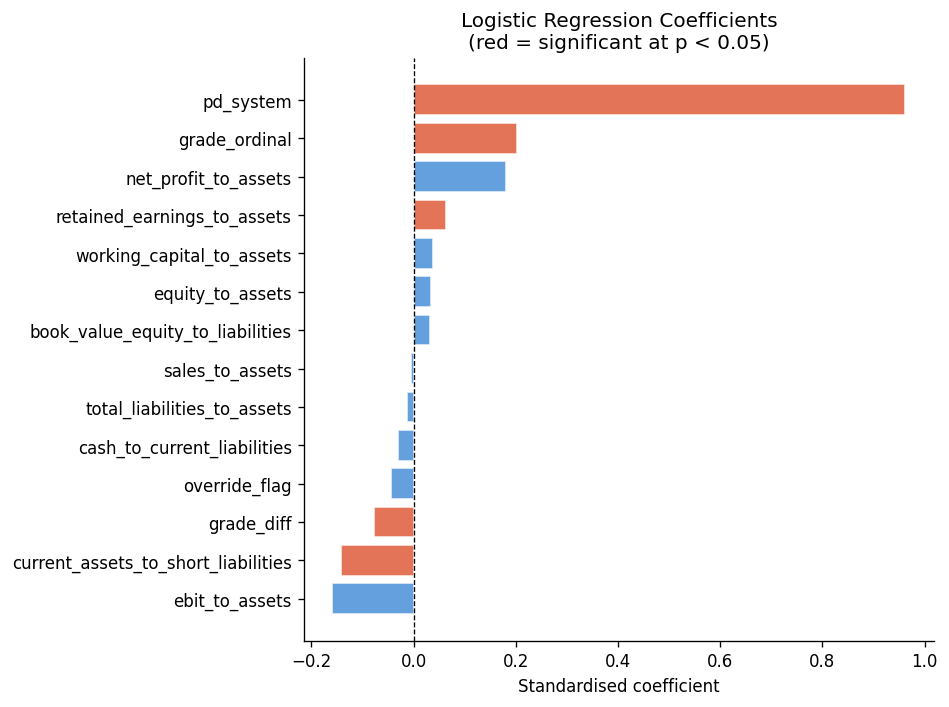

Figure saved: 09_coefficient_plot.png


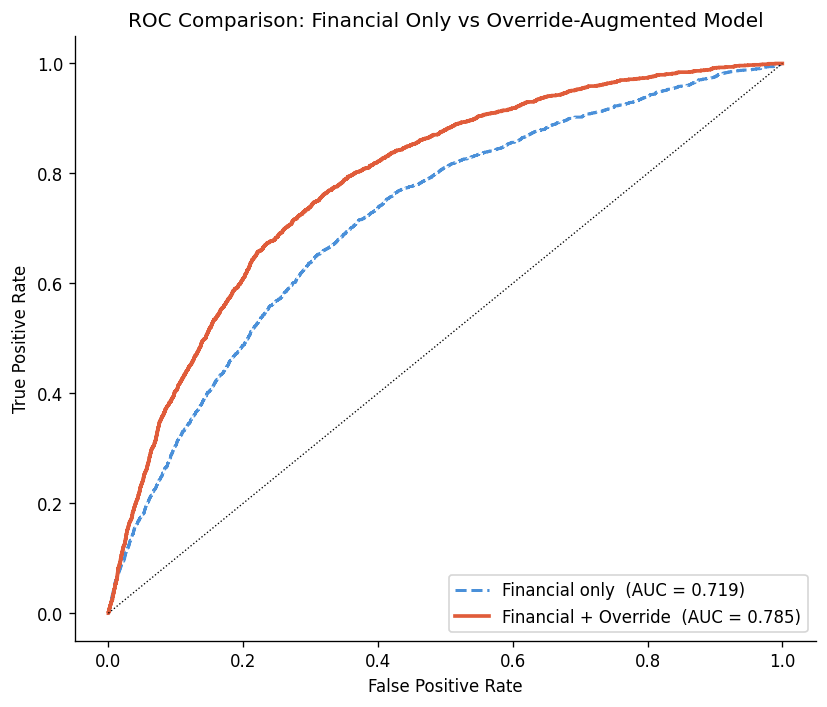

AUC – Financial only       : 0.7191
AUC – Financial + Override : 0.7847
ΔAUC                       : +0.0656


In [2]:
# NB05_statistical_model.ipynb

# %% [markdown]
# # NB05 – Statistical Model: Logistic Regression with WoE
# **Purpose:** Fit an interpretable logistic regression using
# Weight-of-Evidence (WoE) transformed features.
#
# **Key research question:**
# Does `grade_diff` (evaluator upgrade magnitude) independently predict
# default probability after controlling for financial variables?
#
# **Input:**  `data/processed/override_data.parquet`
# **Output:**
# - `results/tables/05_woe_iv_table.csv`
# - `results/tables/06_logit_coefficients.csv`
# - `results/figures/08_roc_comparison.png`
# - `results/figures/09_coefficient_plot.png`

# %%
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

df = pd.read_parquet(PROC_DIR + "override_data.parquet")
print(f"Loaded: {df.shape}")
print(f"Default rate: {df['default'].mean():.4f}")

# %% [markdown]
# ## 1. Feature selection

# %%
# Financial features
FINANCIAL_COLS = [
    "net_profit_to_assets",
    "total_liabilities_to_assets",
    "working_capital_to_assets",
    "current_assets_to_short_liabilities",
    "cash_to_current_liabilities",
    "retained_earnings_to_assets",
    "ebit_to_assets",
    "book_value_equity_to_liabilities",
    "sales_to_assets",
    "equity_to_assets",
]
FINANCIAL_COLS = [c for c in FINANCIAL_COLS if c in df.columns]

# Override features (core variables of interest)
OVERRIDE_COLS = ["pd_system", "grade_ordinal", "grade_diff", "override_flag"]
OVERRIDE_COLS = [c for c in OVERRIDE_COLS if c in df.columns]

ALL_FEATURES = FINANCIAL_COLS + OVERRIDE_COLS

y = df["default"]
print(f"Financial features : {len(FINANCIAL_COLS)}")
print(f"Override features  : {len(OVERRIDE_COLS)}")

# %% [markdown]
# ## 2. Weight of Evidence (WoE) & Information Value (IV)

# %%
def compute_woe_iv(series: pd.Series, target: pd.Series,
                   n_bins: int = 10) -> pd.DataFrame:
    """Compute WoE and IV for a continuous feature."""
    data = pd.DataFrame({"x": series, "y": target}).dropna()
    data["bin"] = pd.qcut(data["x"], q=n_bins, duplicates="drop")

    grp = data.groupby("bin", observed=True)["y"].agg(["sum", "count"])
    grp.columns = ["events", "total"]
    grp["non_events"] = grp["total"] - grp["events"]

    eps      = 1e-6
    total_e  = grp["events"].sum()
    total_ne = grp["non_events"].sum()

    grp["pct_e"]  = grp["events"]     / (total_e  + eps)
    grp["pct_ne"] = grp["non_events"] / (total_ne + eps)
    grp["woe"]    = np.log((grp["pct_e"] + eps) / (grp["pct_ne"] + eps))
    grp["iv"]     = (grp["pct_e"] - grp["pct_ne"]) * grp["woe"]
    return grp


iv_records = []
for feat in ALL_FEATURES:
    try:
        woe_df = compute_woe_iv(df[feat], y)
        iv_val = woe_df["iv"].sum()
    except Exception:
        iv_val = np.nan
    iv_records.append({"feature": feat, "IV": round(iv_val, 4)})

iv_df = pd.DataFrame(iv_records).sort_values("IV", ascending=False)
iv_df["strength"] = pd.cut(
    iv_df["IV"],
    bins  = [-np.inf, 0.02, 0.1, 0.3, 0.5, np.inf],
    labels= ["Useless", "Weak", "Medium", "Strong", "Very strong"],
)

print("Information Value (IV) by feature:")
display(iv_df)
iv_df.to_csv(TABLE_DIR + "05_woe_iv_table.csv", index=False)
print(f"Saved: {TABLE_DIR}05_woe_iv_table.csv")

# %% [markdown]
# ## 3. Logistic regression with statsmodels
# Provides coefficient p-values and confidence intervals for the paper.

# %%
from sklearn.preprocessing import StandardScaler

X_raw    = df[ALL_FEATURES].fillna(0)
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index,
)

X_sm      = sm.add_constant(X_scaled)
logit_mdl = sm.Logit(y, X_sm).fit(maxiter=300, disp=False)

print(logit_mdl.summary2())

# %% [markdown]
# ## 4. Coefficient table (publication-ready)

# %%
coef_df = pd.DataFrame({
    "Coefficient" : logit_mdl.params,
    "Std_Error"   : logit_mdl.bse,
    "z_statistic" : logit_mdl.tvalues,
    "p_value"     : logit_mdl.pvalues,
    "OR"          : np.exp(logit_mdl.params),
    "CI_lower"    : np.exp(logit_mdl.conf_int()[0]),
    "CI_upper"    : np.exp(logit_mdl.conf_int()[1]),
}).drop("const", errors="ignore").round(4)

coef_df["significant"] = coef_df["p_value"] < 0.05

print("\nCoefficient Table:")
display(coef_df)
coef_df.to_csv(TABLE_DIR + "06_logit_coefficients.csv")
print(f"Saved: {TABLE_DIR}06_logit_coefficients.csv")

# grade_diff interpretation
if "grade_diff" in coef_df.index:
    gd_or = coef_df.loc["grade_diff", "OR"]
    gd_p  = coef_df.loc["grade_diff", "p_value"]
    print(f"\ngrade_diff  OR = {gd_or:.4f}  (p = {gd_p:.4f})")
    print("Interpretation: for each 1-notch upgrade (grade_diff = -1),")
    print(f"  the odds of default multiply by {1/gd_or:.4f}.")

# %% [markdown]
# ## 5. Coefficient forest plot

# %%
plot_df = coef_df.drop("const", errors="ignore").copy()
plot_df = plot_df[plot_df.index != "const"].sort_values("Coefficient")

colors = ["#E05C3A" if sig else "#4A90D9"
          for sig in plot_df["significant"]]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df.index, plot_df["Coefficient"],
        color=colors, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Standardised coefficient")
ax.set_title("Logistic Regression Coefficients\n"
             "(red = significant at p < 0.05)")
plt.tight_layout()
plt.savefig(FIG_DIR + "09_coefficient_plot.png", bbox_inches="tight")
plt.show()
print("Figure saved: 09_coefficient_plot.png")

# %% [markdown]
# ## 6. ROC comparison: Model A (financial only) vs Model B (+ override features)

# %%
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model A: financial variables only
X_a  = df[FINANCIAL_COLS].fillna(0)
p_a  = cross_val_predict(
    LogisticRegression(C=0.1, max_iter=500, class_weight="balanced"),
    X_a, y, cv=cv, method="predict_proba"
)[:, 1]

# Model B: financial + override features
X_b  = df[ALL_FEATURES].fillna(0)
p_b  = cross_val_predict(
    LogisticRegression(C=0.1, max_iter=500, class_weight="balanced"),
    X_b, y, cv=cv, method="predict_proba"
)[:, 1]

auc_a = roc_auc_score(y, p_a)
auc_b = roc_auc_score(y, p_b)

fpr_a, tpr_a, _ = roc_curve(y, p_a)
fpr_b, tpr_b, _ = roc_curve(y, p_b)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_a, tpr_a, "--", color="#4A90D9", linewidth=1.8,
        label=f"Financial only  (AUC = {auc_a:.3f})")
ax.plot(fpr_b, tpr_b,  "-", color="#E05C3A", linewidth=2.2,
        label=f"Financial + Override  (AUC = {auc_b:.3f})")
ax.plot([0, 1], [0, 1], "k:", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Comparison: Financial Only vs Override-Augmented Model")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR + "08_roc_comparison.png", bbox_inches="tight")
plt.show()

print(f"AUC – Financial only       : {auc_a:.4f}")
print(f"AUC – Financial + Override : {auc_b:.4f}")
print(f"ΔAUC                       : {auc_b - auc_a:+.4f}")